# Model Evaluation — held-out test split

This notebook reports how the trained CNN performs on data it has never seen.

**Why the test split and not validation?** Validation was used *during*
training: early stopping watched it, `ReduceLROnPlateau` watched it, and
`ModelCheckpoint` chose which weights to keep based on it. The model was, in a
small but real sense, *selected* to do well on validation — so that score is
optimistically biased.

The test split was carved out in Phase 3, written to a CSV, and read by nothing
until this notebook. That is what makes the number below an honest estimate.

**Why accuracy alone is not enough here.** The classes are imbalanced 14.4×, and
a model that always guessed the biggest class would score **29.5%**. Any headline
accuracy has to be read against that floor, and the per-class breakdown matters
more than the average.

In [1]:
import json
import sys
from pathlib import Path

from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

FIGURES = PROJECT_ROOT / "notebooks" / "figures"
METRICS = PROJECT_ROOT / "models" / "evaluation_metrics.json"
print("Project root:", PROJECT_ROOT)

Project root: M:\CROP-DISEASE-DETECTION


## 1. Run the evaluation

`src/evaluate.py` holds all the logic, so the same numbers can be regenerated
from the command line without opening a notebook. This cell just calls it.

In [2]:
import subprocess

# sys.executable, not a bare "python": that guarantees the script runs in the
# same interpreter as this notebook. A plain `!python` would pick up whatever
# is first on PATH, which is usually NOT the project virtualenv.
result = subprocess.run(
    [sys.executable, str(PROJECT_ROOT / "src" / "evaluate.py")],
    capture_output=True, text=True,
)

# TensorFlow writes a wall of CPU/oneDNN notices to stderr; filter them out.
noise = ("oneDNN", "absl::", "cpu_feature_guard", "rebuild TensorFlow",
         "To enable the following", "GPU support", "TF-TRT")
print("\n".join(l for l in result.stdout.splitlines() if not any(n in l for n in noise)))

if result.returncode != 0:
    print("\n--- evaluate.py failed ---")
    print("\n".join(result.stderr.splitlines()[-15:]))

EVALUATION -- held-out test split

Model   : best_model.keras (111,946 parameters)
Test set: 2,724 images across 10 classes

Running inference...

OVERALL
  Test accuracy : 0.7676  (76.76%)
  Test loss     : 0.7188
  Macro F1      : 0.7448   (every class counts equally)
  Weighted F1   : 0.7732   (weighted by class size)
  Majority-class baseline: 29.5%

PER-CLASS
                                      precision    recall  f1-score   support

                      Bacterial_spot       0.54      0.99      0.70       319
                        Early_blight       0.39      0.70      0.50       150
                         Late_blight       0.74      0.66      0.70       286
                           Leaf_Mold       0.84      0.82      0.83       143
                  Septoria_leaf_spot       0.83      0.82      0.82       265
Spider_mites Two-spotted_spider_mite       0.86      0.65      0.74       252
                         Target_Spot       0.98      0.38      0.55       211
       T

## 2. Headline metrics

In [3]:
metrics = json.loads(METRICS.read_text())

acc      = metrics["test_accuracy"]
macro    = metrics["macro_f1"]
weighted = metrics["weighted_f1"]
baseline = metrics["majority_class_baseline"]

print(f"Test images        : {metrics['n_test_images']:,}")
print(f"Test accuracy      : {acc:.2%}")
print(f"Test loss          : {metrics['test_loss']:.4f}")
print(f"Macro F1           : {macro:.4f}")
print(f"Weighted F1        : {weighted:.4f}")
print()
print(f"Majority baseline  : {baseline:.1%}")
print(f"Lift over baseline : {acc - baseline:+.1%}")

Test images        : 2,724
Test accuracy      : 76.76%
Test loss          : 0.7188
Macro F1           : 0.7448
Weighted F1        : 0.7732

Majority baseline  : 29.5%
Lift over baseline : +47.3%


### Macro-F1 vs weighted-F1 — and why the gap matters

Both average the per-class F1 scores; they differ in how they weight them.

- **Weighted-F1** weights each class by how many test images it has. The big
  classes dominate, so it tracks overall accuracy closely.
- **Macro-F1** is a plain unweighted mean — the 373-image mosaic-virus class
  counts exactly as much as the 5,357-image Yellow Leaf Curl class.

**Macro-F1 is the more honest number for this dataset.** A model can post a
respectable weighted-F1 while failing badly on the rare classes, because those
classes barely move the weighted average. If macro-F1 sits well below
weighted-F1, that gap *is* the imbalance problem showing up in the metric.

In [4]:
gap = weighted - macro
print(f"weighted-F1 - macro-F1 = {gap:+.4f}")
print()
if gap > 0.05:
    print("Macro is meaningfully lower: the model is notably weaker on the")
    print("smaller classes than the headline number suggests.")
elif gap > 0.01:
    print("Small gap: performance is fairly even, with some weakness on rare classes.")
else:
    print("Negligible gap: the model performs consistently across classes")
    print("regardless of their size.")

weighted-F1 - macro-F1 = +0.0283

Small gap: performance is fairly even, with some weakness on rare classes.


## 3. Per-class performance

**Precision** — of everything predicted as this class, how much really was.
**Recall** — of everything that really was this class, how much was found.
**F1** — their harmonic mean, punishing a model that wins one by sacrificing the other.

For a diagnostic tool, **recall matters more than precision**: missing a real
disease (false negative) means an untreated crop, while a false alarm costs an
unnecessary inspection.

In [5]:
import pandas as pd

per_class = pd.DataFrame(metrics["per_class"]).T
per_class.index.name = "class"
per_class["support"] = per_class["support"].astype(int)
per_class = per_class.sort_values("f1", ascending=False)
per_class.style.format({"precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}"})

,precision,recall,f1,support
class,,,,
Tomato_mosaic_virus,1.000,0.839,0.913,56
Tomato_Yellow_Leaf_Curl_Virus,0.949,0.871,0.908,804
Leaf_Mold,0.836,0.818,0.827,143
Septoria_leaf_spot,0.826,0.823,0.824,265
healthy,1.000,0.639,0.779,238
Spider_mites Two-spotted_spider_mite,0.864,0.655,0.745,252
Bacterial_spot,0.543,0.991,0.701,319
Late_blight,0.739,0.664,0.700,286
Target_Spot,0.976,0.384,0.551,211


In [6]:
best = per_class.index[0]
worst = per_class.index[-1]

print(f"Best  : {best}")
print(f"        F1 {per_class.loc[best, 'f1']:.3f} | "
      f"recall {per_class.loc[best, 'recall']:.3f} | "
      f"{per_class.loc[best, 'support']} test images")
print()
print(f"Worst : {worst}")
print(f"        F1 {per_class.loc[worst, 'f1']:.3f} | "
      f"recall {per_class.loc[worst, 'recall']:.3f} | "
      f"{per_class.loc[worst, 'support']} test images")
print()
corr = per_class["support"].corr(per_class["f1"])
print(f"Correlation between class size and F1: {corr:+.3f}")
print("(positive => the model does better on classes it saw more of,")
print(" which is the signature of imbalance hurting the rare classes)")

Best  : Tomato_mosaic_virus
        F1 0.913 | recall 0.839 | 56 test images

Worst : Early_blight
        F1 0.500 | recall 0.700 | 150 test images

Correlation between class size and F1: +0.308
(positive => the model does better on classes it saw more of,
 which is the signature of imbalance hurting the rare classes)


## 4. Confusion matrices

Two views of the same data, answering different questions.

**Raw counts** show where the *volume* of errors is — but they are dominated by
the big classes. Fifty mistakes on a 5,357-image class is a 1% error rate; fifty
on a 373-image class would be catastrophic. The raw matrix cannot tell them
apart at a glance.

**Row-normalised** divides each row by its true-class total, so every cell reads
"what fraction of this class was predicted as that". **The diagonal is per-class
recall.** This is the view to trust when classes are imbalanced.

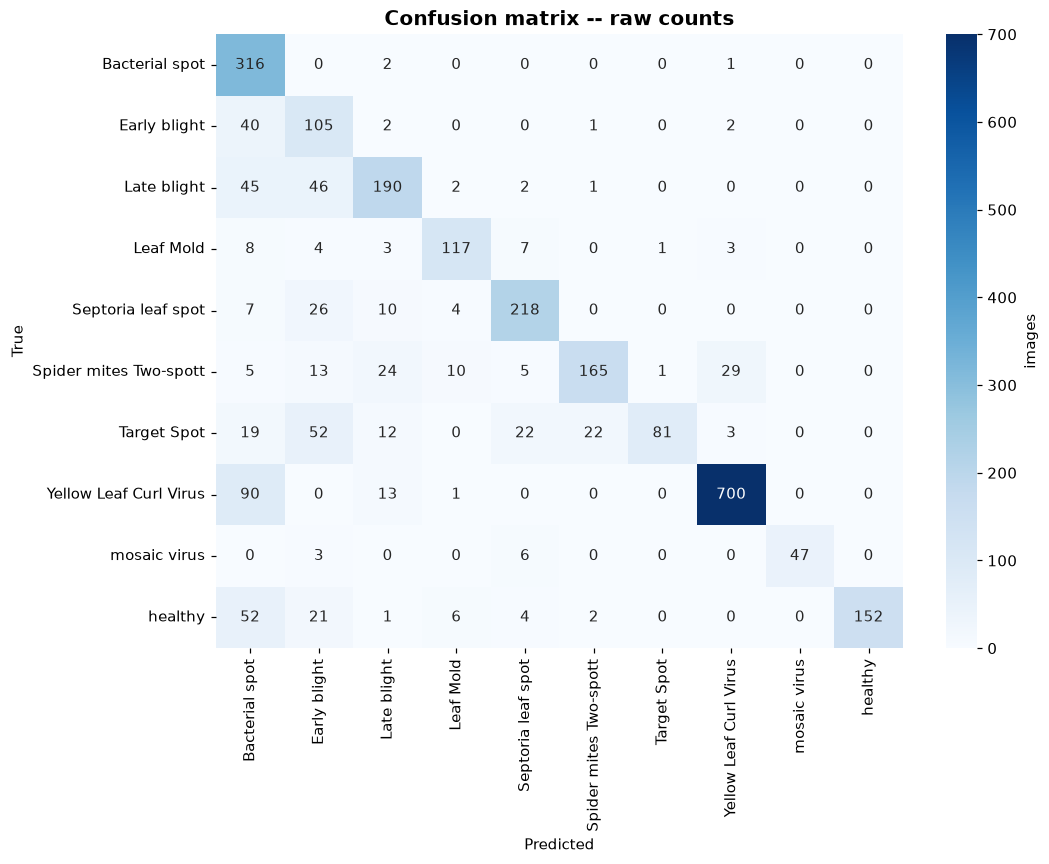

In [7]:
display(Image(filename=str(FIGURES / "confusion_matrix_raw.png")))

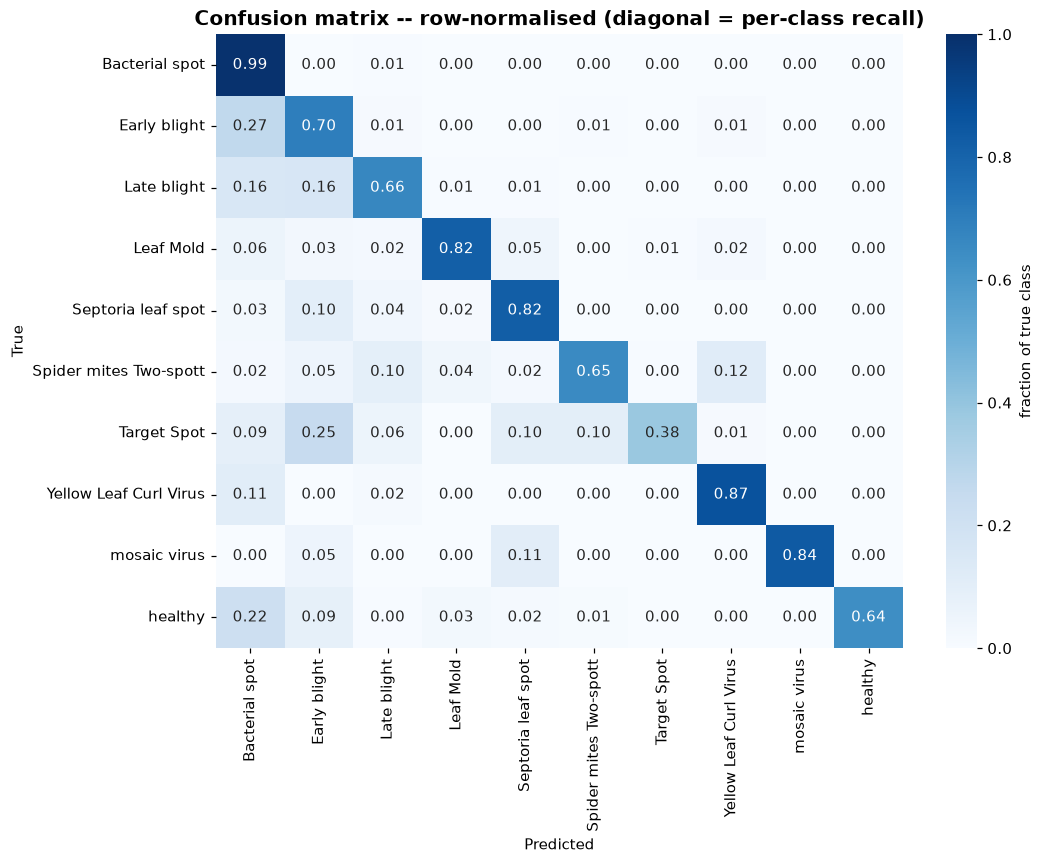

In [8]:
display(Image(filename=str(FIGURES / "confusion_matrix_normalized.png")))

### Which classes get confused with which?

Off-diagonal cells are the interesting part. Confusions between *visually
similar* diseases are expected and forgivable; confusions with **healthy** are
the costly ones, because a diseased plant reported as healthy goes untreated.

In [9]:
print("Top confusions (true -> predicted):\n")
for c in metrics["top_confusions"][:8]:
    t = c["true"].replace("Tomato_", "").replace("_", " ")
    p = c["predicted"].replace("Tomato_", "").replace("_", " ")
    print(f"  {t:<30} -> {p:<30} {c['count']:>4} "
          f"({c['fraction_of_true_class']:.1%} of that class)")

# The dangerous direction: a real disease called healthy.
missed = [c for c in metrics["top_confusions"] if c["predicted"] == "healthy"]
print("\nDiseased leaves predicted as HEALTHY (false negatives):")
if missed:
    for c in missed:
        t = c["true"].replace("Tomato_", "").replace("_", " ")
        print(f"  {t:<30} {c['count']:>4} ({c['fraction_of_true_class']:.1%})")
else:
    print("  none in the top confusions -- good")

Top confusions (true -> predicted):

  Yellow Leaf Curl Virus         -> Bacterial spot                   90 (11.2% of that class)
  Target Spot                    -> Early blight                     52 (24.6% of that class)
  healthy                        -> Bacterial spot                   52 (21.8% of that class)
  Late blight                    -> Early blight                     46 (16.1% of that class)
  Late blight                    -> Bacterial spot                   45 (15.7% of that class)
  Early blight                   -> Bacterial spot                   40 (26.7% of that class)
  Spider mites Two-spotted spider mite -> Yellow Leaf Curl Virus           29 (11.5% of that class)
  Septoria leaf spot             -> Early blight                     26 (9.8% of that class)

Diseased leaves predicted as HEALTHY (false negatives):
  none in the top confusions -- good


## 5. Where it goes wrong

The grid below shows the **most confident** mistakes, not random ones. That
choice is deliberate: an error the model was 99% sure about is far more
diagnostic than one it was torn over. Confident errors expose systematic
confusions between classes; low-confidence errors are just the model admitting
it does not know.

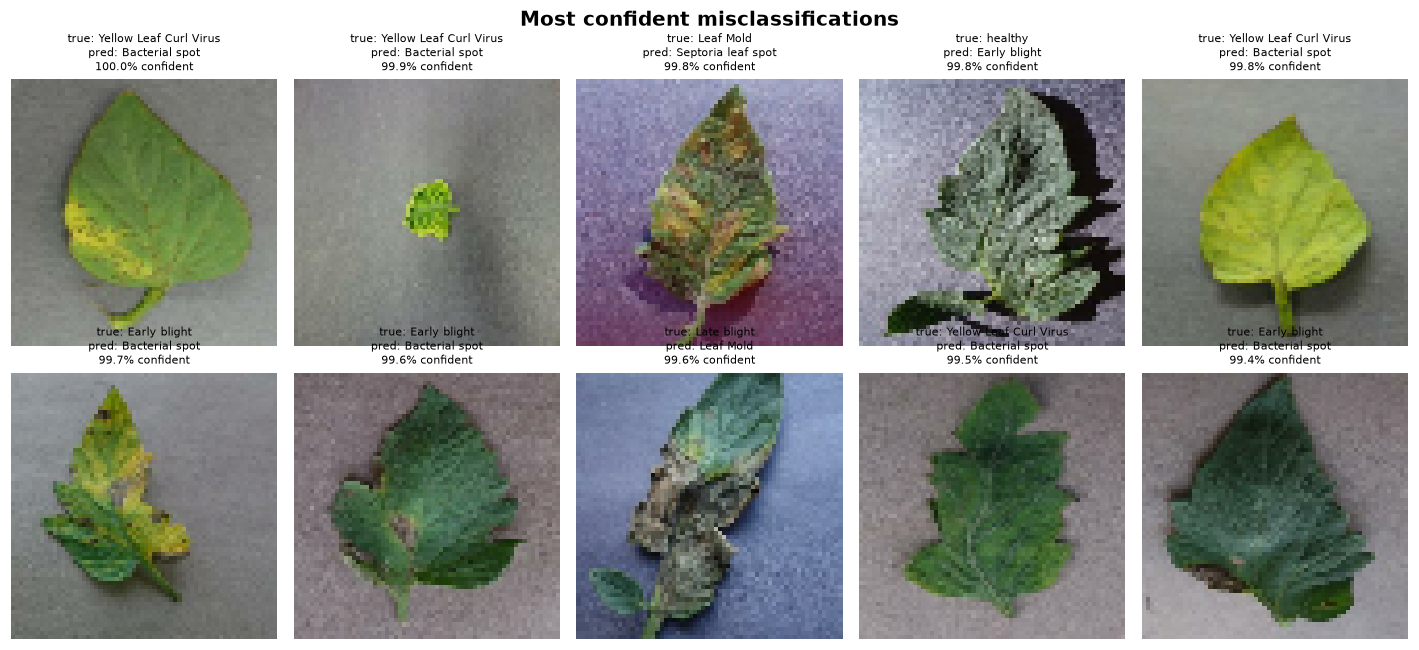

In [10]:
display(Image(filename=str(FIGURES / "misclassifications" / "grid.png")))

In [11]:
print("The model's most confident errors:\n")
for m in metrics["most_confident_misclassifications"][:10]:
    t = m["true"].replace("Tomato_", "").replace("_", " ")
    p = m["predicted"].replace("Tomato_", "").replace("_", " ")
    print(f"  {m['confidence']:.1%} sure it was {p:<26} but it was {t}")

The model's most confident errors:

  100.0% sure it was Bacterial spot             but it was Yellow Leaf Curl Virus
  99.9% sure it was Bacterial spot             but it was Yellow Leaf Curl Virus
  99.8% sure it was Septoria leaf spot         but it was Leaf Mold
  99.8% sure it was Early blight               but it was healthy
  99.8% sure it was Bacterial spot             but it was Yellow Leaf Curl Virus
  99.7% sure it was Bacterial spot             but it was Early blight
  99.6% sure it was Bacterial spot             but it was Early blight
  99.6% sure it was Leaf Mold                  but it was Late blight
  99.5% sure it was Bacterial spot             but it was Yellow Leaf Curl Virus
  99.4% sure it was Bacterial spot             but it was Early blight


## 6. What these results mean

**Read the headline against the baseline, not against 100%.** A majority-class
guesser scores 29.5% here. The lift over that floor is the model's actual
contribution.

**The input resolution is a known constraint.** This model was trained at
64×64 after two larger-footprint runs failed to complete on the available
hardware (see `INTERVIEW_PREP.md`). Fine texture — the speckling that separates
Septoria leaf spot from Target Spot — is largely destroyed at that resolution,
so confusion between those two classes is an expected cost of that trade, not a
modelling error. Retraining at 128×128 on a GPU is the single highest-value
next step.

**The domain gap remains the biggest caveat.** Every image here, train and test
alike, is a lab photograph of a single detached leaf on a plain background. A
strong test score proves the pipeline works; it does not prove the model would
survive a phone photo taken in a field with soil, sky and overlapping foliage in
frame. The test split shares the training distribution, so it cannot measure
that.